# Evalvaluate Predictions

In [1]:
import os
import polars as pl
import pickle
import numpy as np

In [2]:
path_home_deeptan = "/mnt/hdd2/homext/wuch/xn2p"
path_predictions = os.path.join(path_home_deeptan, "run", "predict")
path_raw_df = os.path.join(path_home_deeptan, "data", "raw_df")
path_true_scmul = os.path.join(path_raw_df, "scMultiome", "Ath_scMultiome_WT_split_strata")
path_true_snrna = os.path.join(path_raw_df, "scRNA", "GSE226097_Annotated_split_strata")

In [ ]:
def transform_ct_df(df: pl.DataFrame):
    # 熔化数据框以使每个类别成为一行
    melted_df = df.unpivot(index=["bc"], on=df.columns[1:], variable_name="ct", value_name="value")

    # 过滤出值为1的行，因为每行只有一个1，所以这样可以得到正确的类别名称
    filtered_df = melted_df.filter(pl.col("value") == 1)

    # 选择需要的列
    result_df = filtered_df.select(["bc", "ct"])

    celltypes_ = result_df["ct"].to_list()
    celltypes = [ct.replace("ct_", "") for ct in celltypes_ if ct.startswith("ct_")]
    result_df = result_df.hstack(pl.DataFrame({"ct_": celltypes})).drop("ct").rename({"ct_": "ct", "bc":"obs_names"})

    return result_df

## Load predictions

### scMultiome

In [3]:
dataset = "sc_multiome_minmi0.35_top2000"
predictions_scmul = {
    "multitask": os.path.join(path_predictions, dataset, "preds+seed_42+multitask+tst+DeepTAN_20250414053531_MrU9O.pkl"),
    "multitask_noguide": os.path.join(path_predictions, dataset, "preds+seed_42+multitask_noguide+tst+DeepTAN_20250406160952_ry4p7.pkl"),
    "focus_recon": os.path.join(path_predictions, dataset, "preds+seed_42+focus_recon+tst+DeepTAN_20250405143337_g2qQL.pkl"),
    "focus_label": os.path.join(path_predictions, dataset, "preds+seed_42+focus_label+tst+DeepTAN_20250405014429_4gBXD.pkl"),
}
scmul_f2k_pred_tst = {}
scmul_f2k_pred_tst_fvalues = {}

for _k, _v in predictions_scmul.items():
    with open(_v, "rb") as f:
        scmul_f2k_pred_tst[_k] = pickle.load(f)
    scmul_f2k_pred_tst_fvalues[_k] = np.squeeze(scmul_f2k_pred_tst[_k]["node_recon_all"], axis=-1)

In [4]:
print(scmul_f2k_pred_tst.keys())
print(scmul_f2k_pred_tst["multitask"].keys())
print(scmul_f2k_pred_tst_fvalues["multitask"].shape)

dict_keys(['multitask', 'multitask_noguide', 'focus_recon', 'focus_label'])
dict_keys(['g_embedding', 'node_recon', 'node_recon_all', 'labels', 'dict_node_names', 'output_g_label_dim', 'label_names'])
(564, 2000)


### snRNA-seq

In [5]:
dataset = "sc_rna_annotated_minmi0.0_top2000"
predictions_snrna = {
    "multitask": os.path.join(path_predictions, dataset, "preds+seed_42+multitask+tst+DeepTAN_20250408161134_XJTBS.pkl"),
    "multitask_noguide": os.path.join(path_predictions, dataset, "preds+seed_42+multitask_noguide+tst+DeepTAN_20250412010910_0Fgbn.pkl"),
    "focus_recon": os.path.join(path_predictions, dataset, "preds+seed_42+focus_recon+tst+DeepTAN_20250409002315_58HqI.pkl"),
    "focus_label": os.path.join(path_predictions, dataset, "preds+seed_42+focus_label+tst+DeepTAN_20250409215826_0gwUk.pkl"),
}
snrna_f2k_pred_tst = {}
snrna_f2k_pred_tst_fvalues = {}

for _k, _v in predictions_snrna.items():
    with open(_v, "rb") as f:
        snrna_f2k_pred_tst[_k] = pickle.load(f)
    snrna_f2k_pred_tst_fvalues[_k] = np.squeeze(snrna_f2k_pred_tst[_k]["node_recon_all"], axis=-1)

## Load true data

### scMultiome

In [7]:
seed_ = 42
scmul_true_f2k_tst_f = pl.read_parquet(os.path.join(path_true_scmul, f"split_{seed_}_2.parquet")).select(["obs_names"] + list(scmul_f2k_pred_tst["multitask"]["dict_node_names"].keys()))
# print(scmul_true_f2k_tst_f)
scmul_true_f2k_tst_fvalues = scmul_true_f2k_tst_f.drop(["obs_names"]).to_numpy()

# Apply log1p
scmul_true_f2k_tst_fvalues = np.log1p(scmul_true_f2k_tst_fvalues)

print(scmul_true_f2k_tst_fvalues.shape)

(564, 2000)


In [42]:
scmul_true_labels_df = pl.read_parquet(os.path.join(os.path.dirname(path_true_scmul), "Ath_scMultiome_WT_celltypes_onehot.parquet"))
scmul_true_labels_all = transform_ct_df(scmul_true_labels_df)

scmul_true_labels_tst = scmul_true_labels_all.join(scmul_true_f2k_tst_f, on="obs_names", how="right").select(["obs_names", "ct"])
print(scmul_true_labels_tst)

shape: (564, 2)
┌──────────────────────────┬─────────────┐
│ obs_names                ┆ ct          │
│ ---                      ┆ ---         │
│ str                      ┆ str         │
╞══════════════════════════╪═════════════╡
│ CK_ATGAAGCCACATGCTA-1    ┆ Cortex      │
│ CK_CACCAACCAGGCTACT-1    ┆ Trichoblast │
│ CK_ATCCATAAGGCTTAGT-1    ┆ Columella   │
│ CK_GTCCTCCCAATGCCCG-1    ┆ Cortex      │
│ AT-CK_TTACGTTTCTAAATCG-1 ┆ Trichoblast │
│ …                        ┆ …           │
│ CK_TGCACCTTCCACCTTA-1    ┆ Initials    │
│ CK_TTAAGGACAGGCGAGT-1    ┆ Initials    │
│ CK_AAATCCGGTGATTTGG-1    ┆ Trichoblast │
│ CK_TCGTTAGCAAACGCGA-1    ┆ Stele       │
│ CK_AAGGTATAGTCTTGAA-1    ┆ Endodermis  │
└──────────────────────────┴─────────────┘


### snRNA-seq

In [9]:
seed_ = 42
snrna_true_f2k_tst_f = pl.read_parquet(os.path.join(path_true_snrna, f"split_{seed_}_2.parquet")).select(["obs_names"] + list(snrna_f2k_pred_tst["multitask"]["dict_node_names"].keys()))
snrna_true_f2k_tst_fvalues = snrna_true_f2k_tst_f.drop(["obs_names"]).to_numpy()

# Apply log1p
snrna_true_f2k_tst_fvalues = np.log1p(snrna_true_f2k_tst_fvalues)

print(snrna_true_f2k_tst_fvalues.shape)

(679, 2000)


In [45]:
snrna_true_labels_df = pl.read_parquet(os.path.join(os.path.dirname(path_true_snrna), "GSE226097_Annotated_celltypes_onehot.parquet"))
snrna_true_labels_all = transform_ct_df(snrna_true_labels_df)

snrna_true_labels_tst = snrna_true_labels_all.join(snrna_true_f2k_tst_f, on="obs_names", how="right").select(["obs_names", "ct"])
print(snrna_true_labels_tst)

shape: (679, 2)
┌──────────────────────┬───────────┐
│ obs_names            ┆ ct        │
│ ---                  ┆ ---       │
│ str                  ┆ str       │
╞══════════════════════╪═══════════╡
│ GCACGGTCAAGTAGTA-1_5 ┆ Epidermal │
│ CGCCAGAAGCCTATCA-1_4 ┆ Epidermal │
│ CAGGTATCATCCCACT-1_1 ┆ Epidermal │
│ AATGGAATCTGGGCCA-1_2 ┆ Epidermal │
│ CGCATGGCAGCTCCTT-1_3 ┆ Epidermal │
│ …                    ┆ …         │
│ TCAATTCTCAGGAAGC-1_4 ┆ Guard     │
│ TATCAGGAGGTTCAGG-1_1 ┆ Epidermal │
│ TTACGTTCATAACTCG-1_2 ┆ Epidermal │
│ CAGATCAAGCCTTGAT-1_4 ┆ Epidermal │
│ GAACTGTCAGTCGCTG-1_1 ┆ Epidermal │
└──────────────────────┴───────────┘


## Computing metrics

In [11]:
from deeptan.utils.metrics import RegressionMetricsCalculator

/home/wuch/miniforge3/envs/sc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### For feature recon

#### scMultiome

In [12]:
metrics_feature_recon_scmul = {}
for _k, _v in scmul_f2k_pred_tst_fvalues.items():
    _calculator = RegressionMetricsCalculator(scmul_true_f2k_tst_fvalues, _v)
    metrics_feature_recon_scmul[_k] = _calculator.calculate_all_metrics()

#### snRNA-seq

In [13]:
metrics_feature_recon_snrna = {}
for _k, _v in snrna_f2k_pred_tst_fvalues.items():
    _calculator = RegressionMetricsCalculator(snrna_true_f2k_tst_fvalues, _v)
    metrics_feature_recon_snrna[_k] = _calculator.calculate_all_metrics()

### Make summary table across tasks

In [14]:
def make_metrics_summary_table(metrics_dict: dict):
    _tasks = list(metrics_dict.keys())
    _dfs = []
    for _task in _tasks:
        _tmp_df = metrics_dict[_task]["averaged"]
        _tmp_df = pl.DataFrame({"task": [_task] * _tmp_df.shape[0]}).hstack(_tmp_df)
        _dfs.append(_tmp_df)
    return pl.concat(_dfs)

#### scMultiome

In [15]:
metrics_feature_recon_scmul["summary"] = make_metrics_summary_table(metrics_feature_recon_scmul)
print(metrics_feature_recon_scmul["summary"])

shape: (16, 4)
┌───────────────────┬────────┬─────────────┬──────────────┐
│ task              ┆ metric ┆ sample_mean ┆ feature_mean │
│ ---               ┆ ---    ┆ ---         ┆ ---          │
│ str               ┆ str    ┆ f64         ┆ f64          │
╞═══════════════════╪════════╪═════════════╪══════════════╡
│ multitask         ┆ mse    ┆ 0.439607    ┆ 0.439607     │
│ multitask         ┆ mae    ┆ 0.334506    ┆ 0.334506     │
│ multitask         ┆ jsd    ┆ inf         ┆ inf          │
│ multitask         ┆ pcc    ┆ 0.338863    ┆ -0.002927    │
│ multitask_noguide ┆ mse    ┆ 0.440726    ┆ 0.440726     │
│ …                 ┆ …      ┆ …           ┆ …            │
│ focus_recon       ┆ pcc    ┆ 0.335289    ┆ -0.017433    │
│ focus_label       ┆ mse    ┆ 0.391573    ┆ 0.391573     │
│ focus_label       ┆ mae    ┆ 0.45423     ┆ 0.45423      │
│ focus_label       ┆ jsd    ┆ inf         ┆ inf          │
│ focus_label       ┆ pcc    ┆ 0.013029    ┆ -0.000648    │
└───────────────────┴────

#### snRNA-seq

In [16]:
metrics_feature_recon_snrna["summary"] = make_metrics_summary_table(metrics_feature_recon_snrna)
print(metrics_feature_recon_snrna["summary"])

shape: (16, 4)
┌───────────────────┬────────┬─────────────┬──────────────┐
│ task              ┆ metric ┆ sample_mean ┆ feature_mean │
│ ---               ┆ ---    ┆ ---         ┆ ---          │
│ str               ┆ str    ┆ f64         ┆ f64          │
╞═══════════════════╪════════╪═════════════╪══════════════╡
│ multitask         ┆ mse    ┆ 0.159071    ┆ 0.159071     │
│ multitask         ┆ mae    ┆ 0.296741    ┆ 0.296741     │
│ multitask         ┆ jsd    ┆ inf         ┆ inf          │
│ multitask         ┆ pcc    ┆ 0.296923    ┆ 0.013049     │
│ multitask_noguide ┆ mse    ┆ 0.139442    ┆ 0.139442     │
│ …                 ┆ …      ┆ …           ┆ …            │
│ focus_recon       ┆ pcc    ┆ 0.286019    ┆ 0.024372     │
│ focus_label       ┆ mse    ┆ 0.12071     ┆ 0.12071      │
│ focus_label       ┆ mae    ┆ 0.291882    ┆ 0.291882     │
│ focus_label       ┆ jsd    ┆ inf         ┆ inf          │
│ focus_label       ┆ pcc    ┆ -0.008437   ┆ -0.026116    │
└───────────────────┴────

## Plot

In [23]:
# Choose a dataset to plot
_dataset = metrics_feature_recon_snrna

dim = "sample_metrics"
# dim = "feature_metrics"

met = ["mse", "mae", "pcc"]
met_text = ["MSE", "MAE", "PCC"]

x_lab = "multitask"
x_lab_text = "Multitask"

# y_labs = ["multitask_noguide", "focus_recon", "focus_label"]
# y_labs_text = ["Multitask (no SGG)", "Focus on reconstruction", "Focus on labelling"]
y_labs = ["focus_recon", "focus_label"]
y_labs_text = ["Focus on reconstruction", "Focus on labelling"]

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

%config InlineBackend.figure_format = 'retina'
%config InlineBackend.figure_dpi = 300

In [19]:
def format_ticks(x, pos):
    return f"{x:.2f}"  # 保留两位小数

/tmp/ipykernel_536397/3809937899.py:103: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


<Figure size 640x480 with 0 Axes>

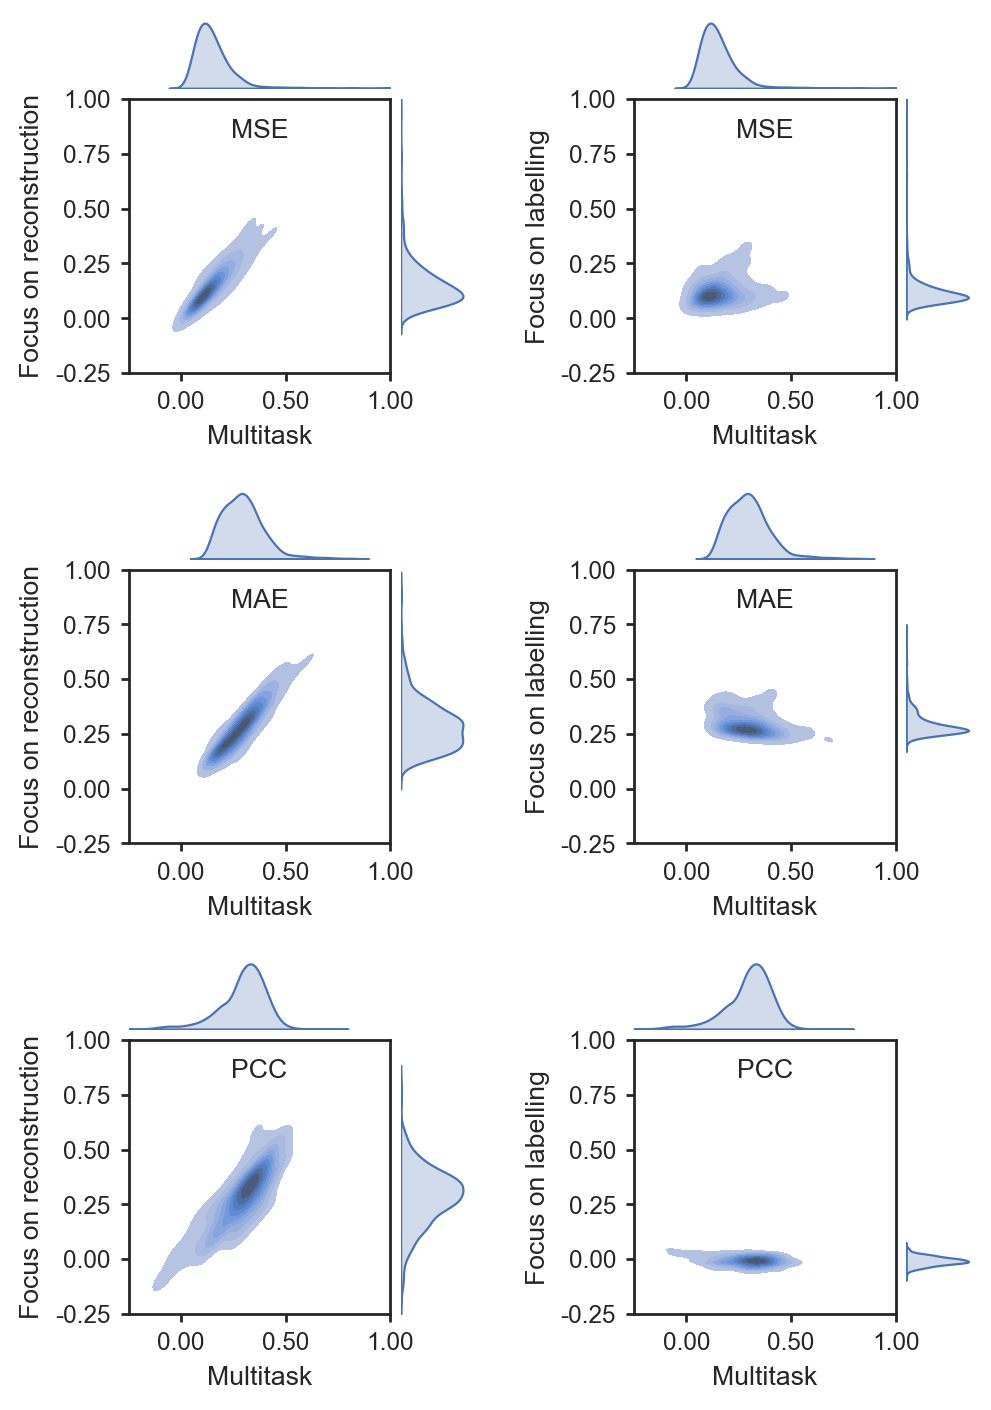

In [24]:
# Try clearing the previous plot if it exists
try:
    plt.clf()
except:
    pass

# A4纸的宽度约为21厘米（8.27英寸），高度可以根据需要调整
# a4_width_cm = 21
# cm_to_inches = 0.393701
# a4_width_inches = a4_width_cm * cm_to_inches
n_cols = len(y_labs)
n_rows = len(met)

fig_width = 2.6 * n_cols  # 调整图表的整体宽度以适应列数
fig_height = 2.4 * n_rows  # 调整图表的整体高度以适应行数

sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.0)  # 设置图表的上下文和字体大小

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(fig_width, fig_height),
    sharex=False,  # 不共享 x 轴
    sharey=False,  # 不共享 y 轴
)

if n_rows == 1:
    axes = axes.reshape(1, -1)

# 用于存储每行的 x 和 y 的最小值和最大值
row_limits = []

for i, _met in enumerate(met):
    row_x_min, row_x_max = float(-0.25), float(1.0)
    row_y_min, row_y_max = float(-0.25), float(1.0)

    for j, y_lab in enumerate(y_labs):
        ax = axes[i, j]
        x_data = _dataset[x_lab][dim][_met]["values"]
        y_data = _dataset[y_lab][dim][_met]["values"]

        sns.kdeplot(
            ax=ax,
            x=x_data,
            y=y_data,
            fill=True,
        )
        # 手动添加边缘直方图
        ax_histx = ax.inset_axes((0.0, 1.04, 1.0, 0.25), sharex=ax)
        ax_histy = ax.inset_axes((1.04, 0.0, 0.25, 1.0), sharey=ax)
        sns.kdeplot(x=_dataset[x_lab][dim][_met]["values"], ax=ax_histx, fill=True, legend=False)
        sns.kdeplot(y=_dataset[y_lab][dim][_met]["values"], ax=ax_histy, fill=True, legend=False)
        # 移除边缘分布图的刻度、标签和边框
        ax_histx.set_ylabel(None)
        ax_histy.set_xlabel(None)
        ax_histx.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        ax_histy.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
        for spine in ax_histx.spines.values():
            spine.set_visible(False)
        for spine in ax_histy.spines.values():
            spine.set_visible(False)
        # 禁用网格
        ax_histx.grid(False)
        ax_histy.grid(False)

        # 设置标题和标签
        ax.set_title(met_text[i], y=0.8)
        ax.set_xlabel(x_lab_text)
        ax.set_ylabel(y_labs_text[j])

        # 更新当前行的 x 和 y 的最小值和最大值
        row_x_min = row_x_min if np.isnan(min(x_data)) or np.isinf(min(x_data)) else min(row_x_min, min(x_data))
        # row_x_max = row_x_max if np.isnan(max(x_data)) or np.isinf(max(x_data)) else max(row_x_max, max(x_data))
        row_x_max = 1.0
        row_y_min = row_y_min if np.isnan(min(y_data)) or np.isinf(min(y_data)) else min(row_y_min, min(y_data))
        # row_y_max = row_y_max if np.isnan(max(y_data)) or np.isinf(max(y_data)) else max(row_y_max, max(y_data))
        row_y_max = 1.0

        # 设置刻度格式化器
        ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))
        ax.yaxis.set_major_formatter(ticker.FuncFormatter(format_ticks))

        # 缩短刻度棒的长度
        ax.tick_params(axis="both", which="major", length=3)  # 主刻度棒长度
        ax.tick_params(axis="both", which="minor", length=2)  # 次刻度棒长度

    # 保存当前行的最小值和最大值
    row_limits.append(((row_x_min, row_x_max), (row_y_min, row_y_max)))

    # ax = axes[i, j+1]
    # sns.barplot(x=[x_lab_text]+y_labs_text, y=_dataset[y_lab][dim][_met]["mean"])

# 统一设置每行的 x 和 y 轴范围
for i, (_met, (x_limits, y_limits)) in enumerate(zip(met, row_limits)):
    for j, y_lab in enumerate(y_labs):
        ax = axes[i, j]
        ax.set_xlim(x_limits)
        ax.set_ylim(y_limits)

# fig.subplots_adjust(wspace=0.4, hspace=0.3)
fig.tight_layout()
fig.show()

### PaCMAP

In [33]:
import pacmap
import numpy as np
import matplotlib.pyplot as plt

In [30]:
print(snrna_f2k_pred_tst.keys())
print(snrna_f2k_pred_tst["multitask"].keys())
print(snrna_f2k_pred_tst["multitask"]["g_embedding"].shape)
print(snrna_f2k_pred_tst["multitask"]["node_recon"].shape)
print(snrna_f2k_pred_tst["multitask"]["labels"].shape)

dict_keys(['multitask', 'multitask_noguide', 'focus_recon', 'focus_label'])
dict_keys(['g_embedding', 'node_recon', 'node_recon_all', 'labels', 'dict_node_names', 'output_g_label_dim', 'label_names'])
(679, 256)
(679, 2000, 256)
(679, 5)


In [67]:
all_celltypes = snrna_f2k_pred_tst["multitask"]["label_names"][1:]

y_pred_numeric = snrna_f2k_pred_tst["multitask"]["labels"].argmax(axis=1)
y_pred_text = [all_celltypes[i].replace("ct_", "") for i in y_pred_numeric]

In [ ]:
X = snrna_f2k_pred_tst["multitask"]["g_embedding"]
y_true_text = snrna_true_labels_tst["ct"].to_list()

In [ ]:
embedding = pacmap.PaCMAP(n_components=2, n_neighbors=None, MN_ratio=0.5, FP_ratio=2.0)

# fit the data (The index of transformed data corresponds to the index of the original data)
X_transformed = embedding.fit_transform(X, init="pca")

<Axes: >

<Figure size 640x480 with 0 Axes>

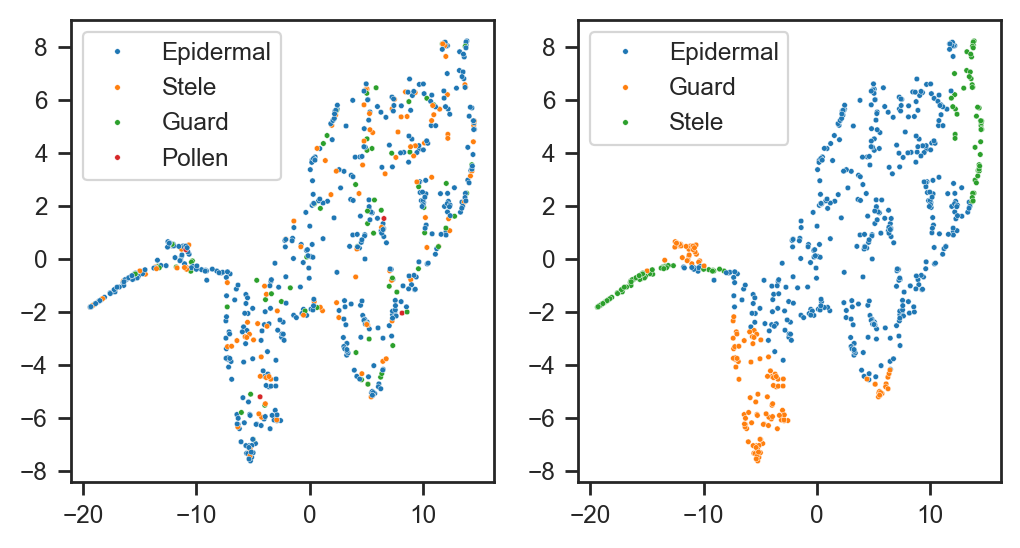

In [78]:
assert X_transformed is not None

try:
    plt.clf()
except:
    pass


sns.set_theme(style="ticks")
sns.set_context("paper", font_scale=1.0)  # 设置图表的上下文和字体大小
# visualize the embedding
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

sns.scatterplot(x=X_transformed[:, 0], y=X_transformed[:, 1], hue=y_true_text, palette="tab10", s=4, ax=ax[0])
sns.scatterplot(x=X_transformed[:, 0], y=X_transformed[:, 1], hue=y_pred_text, palette="tab10", s=4, ax=ax[1])
